# Retail + Finance Forecasting, Risk & Multi-Agent Platform
## Flagship Portfolio Project — Full Pipeline

Single consolidated notebook, run top to bottom. Built on the real M5 Forecasting - Accuracy
dataset (Walmart, Kaggle) -- 58M+ rows of real daily sales, 2011-2016, 10 stores across CA/TX/WI.

**Sections in this notebook:**
1. Exploratory Data Analysis
2. Forecasting Model Comparison (Prophet vs ARIMA vs LightGBM, store level)
3. Global Item x Store LightGBM Model
4. Finance & Risk Layer (revenue forecast, risk scoring, SHAP)
5. RAG Layer (plain-English Q&A over the risk data)

**Before running:** see the project README for setup steps (install requirements, place M5
CSVs in `data/raw/`, run `sql/load_data.py` to build the database, and set `GROQ_API_KEY`
in a `.env` file for Section 5).

---


---
# PHASE 1.5 — Exploratory Data Analysis
---

# Phase 1.5 — Exploratory Data Analysis
## Retail + Finance Forecasting, Risk & Multi-Agent Platform

**Dataset:** M5 Forecasting - Accuracy (Walmart), Kaggle — real daily sales, 2011–2016, 10 stores across CA/TX/WI, 3,049 products.

**Goal of this notebook:** understand the data's real structure — trend, seasonality, sparsity, category/store mix, and the SNAP economic signal — before choosing a forecasting approach in Phase 2.


## 1. Setup & Connect to the SQL Database

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

DB_PATH = "C:/Users/Praveen TS/Downloads/retail_finance_flagship/data/processed/retail_finance.db"
conn = sqlite3.connect(DB_PATH)

# Quick row-count sanity check across all tables
tables = ["dim_item", "dim_store", "dim_calendar", "dim_price", "fact_sales"]
for t in tables:
    n = pd.read_sql(f"SELECT COUNT(*) as n FROM {t}", conn).iloc[0, 0]
    print(f"{t:<15} {n:>12,} rows")


dim_item               3,049 rows
dim_store                 10 rows
dim_calendar           1,969 rows
dim_price          6,841,121 rows
fact_sales        59,181,090 rows


## 2. Monthly Sales Trend

Aggregating 58M daily rows up to monthly totals to see the big-picture trend and seasonality.

In [2]:
query_monthly = '''
SELECT c.year, c.month, SUM(f.units_sold) AS total_units
FROM fact_sales f
JOIN dim_calendar c ON f.d = c.d
GROUP BY c.year, c.month
ORDER BY c.year, c.month
'''
monthly = pd.read_sql(query_monthly, conn)
monthly["year_month"] = pd.to_datetime(monthly["year"].astype(str) + "-" + monthly["month"].astype(str) + "-01")
monthly.head()


,year,month,total_units,year_month
0,2011,1,88163,2011-01-01
1,2011,2,726375,2011-02-01
2,2011,3,763567,2011-03-01
3,2011,4,737713,2011-04-01
4,2011,5,719562,2011-05-01


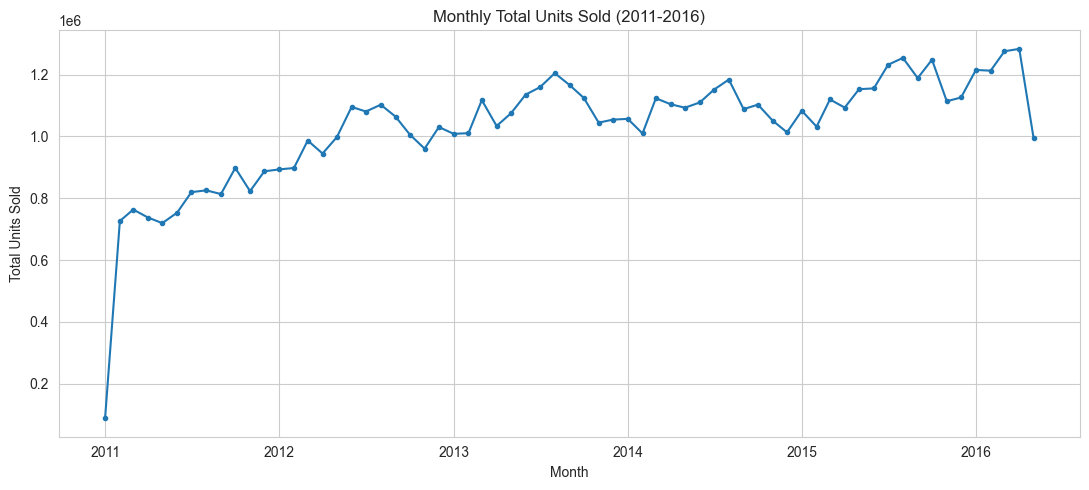

In [3]:
plt.figure()
plt.plot(monthly["year_month"], monthly["total_units"], marker="o", markersize=3, linewidth=1.5)
plt.title("Monthly Total Units Sold (2011-2016)")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.tight_layout()
plt.show()


**Observation:** Steady growth from ~720K units/month (2011) to ~1.2-1.3M/month (2016), with visible seasonal peaks in summer months. Note the low Jan-2011 point is a partial-month artifact (data starts Jan 29, 2011, not the 1st) — not a real dip. *(Fill in your own read after running: does growth look linear or accelerating? Any months that surprise you?)*

## 3. Category & Store Breakdown

In [4]:
query_cat = '''
SELECT i.cat_id, SUM(f.units_sold) AS total_units, COUNT(DISTINCT f.item_id) AS num_items
FROM fact_sales f JOIN dim_item i ON f.item_id = i.item_id
GROUP BY i.cat_id ORDER BY total_units DESC
'''
cat_df = pd.read_sql(query_cat, conn)
cat_df


,cat_id,total_units,num_items
0,FOODS,45922427,1437
1,HOUSEHOLD,14764090,1047
2,HOBBIES,6240656,565


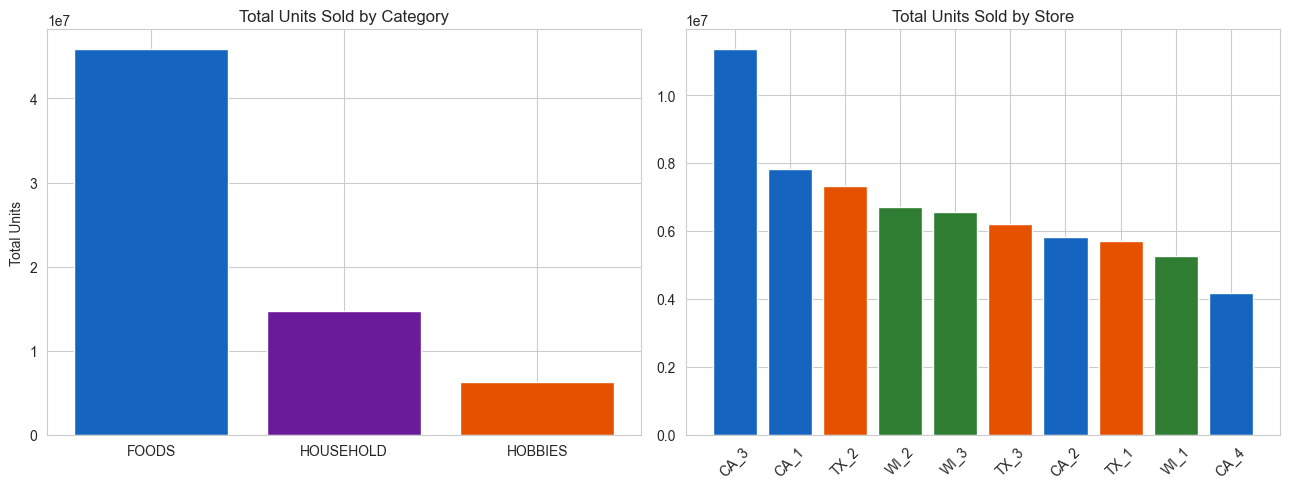

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(cat_df["cat_id"], cat_df["total_units"], color=["#1565C0", "#6A1B9A", "#E65100"])
axes[0].set_title("Total Units Sold by Category")
axes[0].set_ylabel("Total Units")

query_store = '''
SELECT s.store_id, s.state_id, SUM(f.units_sold) AS total_units
FROM fact_sales f JOIN dim_store s ON f.store_id = s.store_id
GROUP BY s.store_id, s.state_id ORDER BY total_units DESC
'''
store_df = pd.read_sql(query_store, conn)
state_colors = {"CA": "#1565C0", "TX": "#E65100", "WI": "#2E7D32"}
axes[1].bar(store_df["store_id"], store_df["total_units"], color=[state_colors[s] for s in store_df["state_id"]])
axes[1].set_title("Total Units Sold by Store")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


**Observation:** FOODS dominates total volume, well ahead of HOUSEHOLD and HOBBIES. Store volume varies substantially even within the same state (compare CA stores to each other) — meaning a single global forecasting model is unlikely to work well; store-level effects matter.

## 4. Demand Sparsity — Zero-Sales Days

This is the single most important structural fact for choosing a forecasting method. At the item x store x day grain, how often is demand actually zero?

In [6]:
query_zero = '''
SELECT
  SUM(CASE WHEN units_sold = 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS pct_zero_days
FROM fact_sales
'''
pct_zero = pd.read_sql(query_zero, conn).iloc[0, 0]
print(f"Zero-sales rate across all item-store-day rows: {pct_zero:.1f}%")


Zero-sales rate across all item-store-day rows: 68.0%


**Observation:** roughly two-thirds of item-store-day combinations are zero. This is **intermittent demand** — very common in retail at the SKU x store grain. Classical smooth-curve methods (plain Prophet/ARIMA) tend to struggle here; tree-based methods (LightGBM/XGBoost) generally handle zero-inflation better. This is the core hypothesis Phase 2's model comparison needs to test, not assume.

## 5. SNAP (Food Assistance) Effect on FOODS Sales

In [7]:
query_snap = '''
SELECT s.state_id,
  CASE WHEN s.state_id = 'CA' THEN c.snap_CA
       WHEN s.state_id = 'TX' THEN c.snap_TX
       WHEN s.state_id = 'WI' THEN c.snap_WI END AS is_snap_day,
  AVG(f.units_sold) AS avg_units
FROM fact_sales f
JOIN dim_store s ON f.store_id = s.store_id
JOIN dim_item i ON f.item_id = i.item_id
JOIN dim_calendar c ON f.d = c.d
WHERE i.cat_id = 'FOODS'
GROUP BY s.state_id, is_snap_day
ORDER BY s.state_id, is_snap_day
'''
snap_df = pd.read_sql(query_snap, conn)
snap_pivot = snap_df.pivot(index="state_id", columns="is_snap_day", values="avg_units")
snap_pivot.columns = ["Non-SNAP day", "SNAP day"]
snap_pivot["% lift"] = (snap_pivot["SNAP day"] / snap_pivot["Non-SNAP day"] - 1) * 100
snap_pivot


,Non-SNAP day,SNAP day,% lift
state_id,,,
CA,1.693801,1.867325,10.244608
TX,1.497022,1.730998,15.629489
WI,1.437288,1.867776,29.951379


**Observation:** SNAP days show a consistent, real lift in FOODS sales across all three states (roughly +10-30%). This is a genuine economic signal, not noise — worth engineering in as a feature for Phase 2, and it ties directly into the finance/risk story later (state assistance timing affects revenue predictability).

## 6. Price Data Sanity Check

In [8]:
price_stats = pd.read_sql("SELECT MIN(sell_price) as min_p, MAX(sell_price) as max_p, AVG(sell_price) as avg_p, COUNT(*) as n FROM dim_price", conn)
price_stats


,min_p,max_p,avg_p,n
0,0.01,107.32,4.410952,6841121


In [9]:
# Missing price coverage check: do all item-store combos in fact_sales have a matching price?
query_missing_price = '''
SELECT COUNT(DISTINCT f.item_id || '_' || f.store_id) as sales_pairs
FROM fact_sales f
'''
query_price_pairs = '''
SELECT COUNT(DISTINCT item_id || '_' || store_id) as price_pairs
FROM dim_price
'''
sales_pairs = pd.read_sql(query_missing_price, conn).iloc[0,0]
price_pairs = pd.read_sql(query_price_pairs, conn).iloc[0,0]
print(f"Item-store pairs in sales data: {sales_pairs:,}")
print(f"Item-store pairs with price data: {price_pairs:,}")


Item-store pairs in sales data: 30,490
Item-store pairs with price data: 30,490


*(Fill in after running: are these counts equal? If not, we have a price-coverage gap to handle before Phase 2's elasticity work.)*

## 7. Summary — What This Means for Phase 2

| Finding | Modeling implication |
|---|---|
| Steady trend + seasonality | Prophet/ARIMA should capture the smooth component well |
| ~68% zero-sales days (intermittent demand) | Core challenge — plan to compare Prophet/ARIMA vs LightGBM explicitly on this |
| FOODS >> HOUSEHOLD > HOBBIES | Consider category-level model comparison, not just one global model |
| Store volumes vary widely, even within a state | Store-level features/models needed, not one global average |
| SNAP days lift FOODS sales 10-30% | Real feature to engineer into Phase 2 models |

**Next: Phase 2 — build and compare Prophet, ARIMA, and LightGBM forecasts against this data, with these findings as the hypotheses to test.**


In [11]:
conn.close()

---
# PHASE 2 — Forecasting Model Comparison (Store Level)
---

# Phase 2 — Forecasting Model Comparison
## Prophet vs ARIMA vs LightGBM, Store-Level Daily Demand

**Why store-level for the comparison:** we have 30,490 item-store series — fitting Prophet/ARIMA per series isn't practical (that's thousands of individual model fits). Instead we compare methods properly on the 10 store-level aggregate series, then use a single global LightGBM model for the full item-store granularity in the next notebook (needed for Phase 3's revenue/risk work).

**Evaluation:** 28-day holdout (matches the real M5 competition's evaluation horizon). Primary metric: **WAPE** (Weighted Absolute Percentage Error) — more robust than MAPE when many days have low/zero demand.


## 1. Setup & Pull Store-Level Daily Series

In [10]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import mlflow
import mlflow.sklearn
from pathlib import Path

# DB_PATH = "C:/Users/Praveen TS/Downloads/retail_finance_flagship/data/processed/retail_finance.db"
conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA temp_store = MEMORY")

models_dir = Path.cwd() / "models"
models_dir.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{models_dir / 'mlflow.db'}")
mlflow.set_experiment("phase2_forecasting_comparison")

stores_list = pd.read_sql("SELECT store_id, state_id FROM dim_store", conn)

daily_frames = []
for _, row in stores_list.iterrows():
    q = '''
    SELECT store_id, d, SUM(units_sold) AS total_units
    FROM fact_sales
    WHERE store_id = ?
    GROUP BY d
    '''
    df = pd.read_sql(q, conn, params=(row["store_id"],))
    df["state_id"] = row["state_id"]
    daily_frames.append(df)

store_daily = pd.concat(daily_frames, ignore_index=True)

calendar = pd.read_sql(
    "SELECT d, date, wday, month, year, event_type_1, snap_CA, snap_TX, snap_WI FROM dim_calendar",
    conn
)
store_daily = store_daily.merge(calendar, on="d", how="left")
store_daily["date"] = pd.to_datetime(store_daily["date"])
store_daily["has_event"] = store_daily["event_type_1"].notna().astype(int)
store_daily["snap"] = store_daily.apply(
    lambda r: r["snap_CA"] if r["state_id"] == "CA" else (r["snap_TX"] if r["state_id"] == "TX" else r["snap_WI"]),
    axis=1
)
store_daily = store_daily.sort_values(["store_id", "date"]).reset_index(drop=True)
conn.close()

print(f"Rows: {len(store_daily):,}  |  Stores: {store_daily['store_id'].nunique()}  |  "
      f"Date range: {store_daily['date'].min().date()} to {store_daily['date'].max().date()}")
store_daily.head()

Rows: 19,410  |  Stores: 10  |  Date range: 2011-01-29 to 2016-05-22


,store_id,d,total_units,state_id,date,wday,month,year,event_type_1,snap_CA,snap_TX,snap_WI,has_event,snap
0,CA_1,d_1,4337,CA,2011-01-29,1,1,2011,None,0,0,0,0,0
1,CA_1,d_2,4155,CA,2011-01-30,2,1,2011,None,0,0,0,0,0
2,CA_1,d_3,2816,CA,2011-01-31,3,1,2011,None,0,0,0,0,0
3,CA_1,d_4,3051,CA,2011-02-01,4,2,2011,None,1,1,0,0,1
4,CA_1,d_5,2630,CA,2011-02-02,5,2,2011,None,1,0,1,0,1


## 2. Train/Test Split

Holding out the last 28 days per store as the test set — models never see this period during training.

In [11]:
HORIZON = 28
stores = sorted(store_daily["store_id"].unique())

def get_store_series(store_id):
    df = store_daily[store_daily["store_id"] == store_id].sort_values("date").reset_index(drop=True)
    train = df.iloc[:-HORIZON].copy()
    test = df.iloc[-HORIZON:].copy()
    return train, test

print(f"Stores to model: {stores}")
tr_example, te_example = get_store_series(stores[0])
print(f"Example ({stores[0]}): train={len(tr_example)} days, test={len(te_example)} days")


Stores to model: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
Example (CA_1): train=1913 days, test=28 days


## 3. Evaluation Metric — WAPE

In [12]:
def wape(actual, predicted):
    actual = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    return np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual)) * 100

def rmse(actual, predicted):
    actual = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    return np.sqrt(np.mean((actual - predicted) ** 2))


## 4. Model 1 — Prophet

Fit per store, using built-in weekly seasonality plus SNAP day and event flags as extra regressors.

In [13]:
from prophet import Prophet

def fit_prophet(train, test):
    df = train.rename(columns={"date": "ds", "total_units": "y"})[["ds", "y", "snap", "has_event"]]
    m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
    m.add_regressor("snap")
    m.add_regressor("has_event")
    m.fit(df)

    future = test.rename(columns={"date": "ds"})[["ds", "snap", "has_event"]]
    forecast = m.predict(future)
    return forecast["yhat"].values

prophet_results = {}
for store_id in stores:
    train, test = get_store_series(store_id)
    preds = fit_prophet(train, test)
    preds = np.clip(preds, 0, None)  # sales can't be negative
    prophet_results[store_id] = {
        "wape": wape(test["total_units"], preds),
        "rmse": rmse(test["total_units"], preds),
        "preds": preds,
        "actual": test["total_units"].values,
        "dates": test["date"].values,
    }
    print(f"{store_id}: Prophet WAPE={prophet_results[store_id]['wape']:.2f}%  RMSE={prophet_results[store_id]['rmse']:.1f}")


Importing plotly failed. Interactive plots will not work.
11:12:11 - cmdstanpy - INFO - Chain [1] start processing
11:12:11 - cmdstanpy - INFO - Chain [1] done processing


CA_1: Prophet WAPE=7.59%  RMSE=466.2


11:12:12 - cmdstanpy - INFO - Chain [1] start processing
11:12:12 - cmdstanpy - INFO - Chain [1] done processing


CA_2: Prophet WAPE=9.18%  RMSE=570.5


11:12:13 - cmdstanpy - INFO - Chain [1] start processing
11:12:13 - cmdstanpy - INFO - Chain [1] done processing


...

WI_1: Prophet WAPE=8.59%  RMSE=509.1


11:12:18 - cmdstanpy - INFO - Chain [1] start processing
11:12:18 - cmdstanpy - INFO - Chain [1] done processing


WI_2: Prophet WAPE=14.02%  RMSE=946.0


11:12:19 - cmdstanpy - INFO - Chain [1] start processing
11:12:20 - cmdstanpy - INFO - Chain [1] done processing


WI_3: Prophet WAPE=10.67%  RMSE=547.9


## 5. Model 2 — ARIMA (SARIMAX)

Seasonal ARIMA with weekly seasonality (order chosen for weekly retail patterns: (1,1,1)x(1,1,1,7)).

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_arima(train, test):
    y = train["total_units"].values
    model = SARIMAX(y, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                     enforce_stationarity=False, enforce_invertibility=False)
    fitted = model.fit(disp=False)
    forecast = fitted.forecast(steps=len(test))
    return np.clip(forecast, 0, None)

arima_results = {}
for store_id in stores:
    train, test = get_store_series(store_id)
    preds = fit_arima(train, test)
    arima_results[store_id] = {
        "wape": wape(test["total_units"], preds),
        "rmse": rmse(test["total_units"], preds),
        "preds": preds,
        "actual": test["total_units"].values,
        "dates": test["date"].values,
    }
    print(f"{store_id}: ARIMA WAPE={arima_results[store_id]['wape']:.2f}%  RMSE={arima_results[store_id]['rmse']:.1f}")


CA_1: ARIMA WAPE=6.71%  RMSE=388.3
CA_2: ARIMA WAPE=6.80%  RMSE=427.3
CA_3: ARIMA WAPE=5.18%  RMSE=388.5
CA_4: ARIMA WAPE=6.25%  RMSE=222.2
TX_1: ARIMA WAPE=9.15%  RMSE=383.8
TX_2: ARIMA WAPE=7.85%  RMSE=409.3
TX_3: ARIMA WAPE=10.57%  RMSE=527.5
WI_1: ARIMA WAPE=6.33%  RMSE=324.4
WI_2: ARIMA WAPE=15.15%  RMSE=1145.9
WI_3: ARIMA WAPE=9.87%  RMSE=526.2


## 6. Model 3 — LightGBM

Tree-based model using lag features, rolling statistics, and calendar features. Trained with a recursive forecasting loop (each day's prediction feeds the next day's lag features, since future actuals aren't available at inference time).

In [15]:
import lightgbm as lgb

def make_features(df):
    df = df.copy()
    df["dow"] = df["date"].dt.dayofweek
    for lag in [7, 14, 28]:
        df[f"lag_{lag}"] = df["total_units"].shift(lag)
    df["roll_mean_7"] = df["total_units"].shift(1).rolling(7).mean()
    df["roll_mean_28"] = df["total_units"].shift(1).rolling(28).mean()
    return df

FEATURES = ["wday", "month", "snap", "has_event", "dow", "lag_7", "lag_14", "lag_28", "roll_mean_7", "roll_mean_28"]

def fit_lightgbm_recursive(train, test):
    full = pd.concat([train, test]).reset_index(drop=True)
    full_feat = make_features(full)
    train_feat = full_feat.iloc[:len(train)].dropna(subset=FEATURES)

    model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                               num_leaves=31, random_state=42, verbosity=-1)
    model.fit(train_feat[FEATURES], train_feat["total_units"])

    # Recursive forecasting: predict one day at a time, feeding predictions back as lags
    history = train.copy()
    preds = []
    for i in range(len(test)):
        combined = pd.concat([history, test.iloc[[i]]]).reset_index(drop=True)
        feat_row = make_features(combined).iloc[[-1]]
        pred = model.predict(feat_row[FEATURES])[0]
        pred = max(0, pred)
        preds.append(pred)
        next_row = test.iloc[[i]].copy()
        next_row["total_units"] = pred
        history = pd.concat([history, next_row]).reset_index(drop=True)
    return np.array(preds), model

lgbm_results = {}
lgbm_models = {}
for store_id in stores:
    train, test = get_store_series(store_id)
    preds, model = fit_lightgbm_recursive(train, test)
    lgbm_models[store_id] = model
    lgbm_results[store_id] = {
        "wape": wape(test["total_units"], preds),
        "rmse": rmse(test["total_units"], preds),
        "preds": preds,
        "actual": test["total_units"].values,
        "dates": test["date"].values,
    }
    print(f"{store_id}: LightGBM WAPE={lgbm_results[store_id]['wape']:.2f}%  RMSE={lgbm_results[store_id]['rmse']:.1f}")


CA_1: LightGBM WAPE=6.66%  RMSE=433.3
CA_2: LightGBM WAPE=6.61%  RMSE=413.2
CA_3: LightGBM WAPE=3.87%  RMSE=324.2
CA_4: LightGBM WAPE=8.57%  RMSE=283.0
TX_1: LightGBM WAPE=8.56%  RMSE=391.8
TX_2: LightGBM WAPE=7.77%  RMSE=396.6
TX_3: LightGBM WAPE=8.34%  RMSE=422.8
WI_1: LightGBM WAPE=11.22%  RMSE=596.8
WI_2: LightGBM WAPE=7.28%  RMSE=509.9
WI_3: LightGBM WAPE=5.59%  RMSE=311.1


## 7. Head-to-Head Comparison

In [16]:
summary = []
for store_id in stores:
    summary.append({"store_id": store_id, "model": "Prophet", "WAPE": prophet_results[store_id]["wape"], "RMSE": prophet_results[store_id]["rmse"]})
    summary.append({"store_id": store_id, "model": "ARIMA", "WAPE": arima_results[store_id]["wape"], "RMSE": arima_results[store_id]["rmse"]})
    summary.append({"store_id": store_id, "model": "LightGBM", "WAPE": lgbm_results[store_id]["wape"], "RMSE": lgbm_results[store_id]["rmse"]})

summary_df = pd.DataFrame(summary)
pivot_wape = summary_df.pivot(index="store_id", columns="model", values="WAPE")
pivot_wape["winner"] = pivot_wape.idxmin(axis=1)
pivot_wape


model,ARIMA,LightGBM,Prophet,winner
store_id,,,,
CA_1,6.709638,6.658825,7.591503,LightGBM
CA_2,6.796015,6.614309,9.180030,LightGBM
CA_3,5.179704,3.873431,4.843775,LightGBM
CA_4,6.253358,8.569196,9.790143,ARIMA
TX_1,9.152385,8.557231,8.888134,LightGBM
TX_2,7.848803,7.771709,6.918492,Prophet
TX_3,10.572614,8.344315,8.891782,LightGBM
WI_1,6.330163,11.220247,8.593385,ARIMA
WI_2,15.146201,7.283825,14.021575,LightGBM


In [17]:
print("AVERAGE WAPE ACROSS ALL 10 STORES:")
print(summary_df.groupby("model")["WAPE"].mean().sort_values())
print()
print("WIN COUNT (how many stores each model won on WAPE):")
print(pivot_wape["winner"].value_counts())


AVERAGE WAPE ACROSS ALL 10 STORES:
model
LightGBM    7.448564
ARIMA       8.386061
Prophet     8.939034
Name: WAPE, dtype: float64

WIN COUNT (how many stores each model won on WAPE):
winner
LightGBM    7
ARIMA       2
Prophet     1
Name: count, dtype: int64


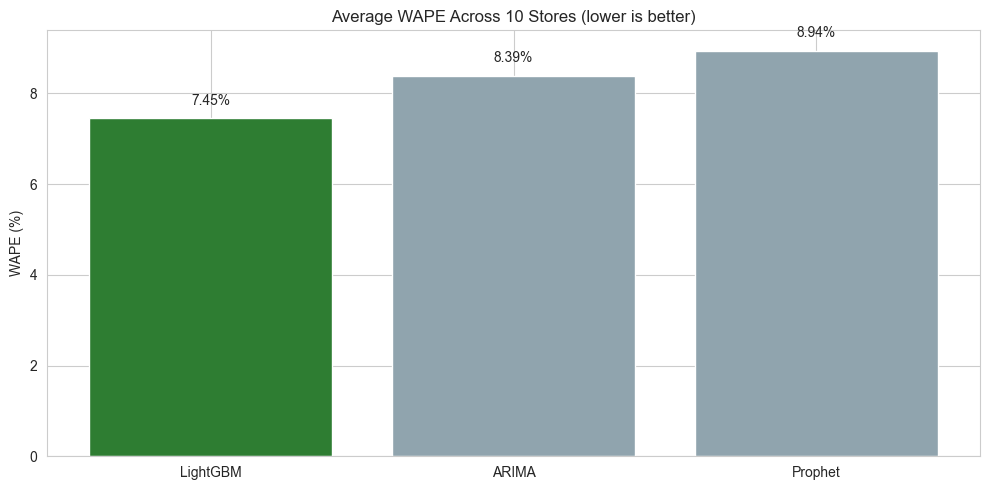

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
avg_wape = summary_df.groupby("model")["WAPE"].mean().sort_values()
colors = ["#2E7D32" if m == avg_wape.index[0] else "#90A4AE" for m in avg_wape.index]
ax.bar(avg_wape.index, avg_wape.values, color=colors)
ax.set_title("Average WAPE Across 10 Stores (lower is better)")
ax.set_ylabel("WAPE (%)")
for i, v in enumerate(avg_wape.values):
    ax.text(i, v + 0.3, f"{v:.2f}%", ha="center")
plt.tight_layout()
plt.show()


## 8. Visual Check — Actual vs Predicted for One Store

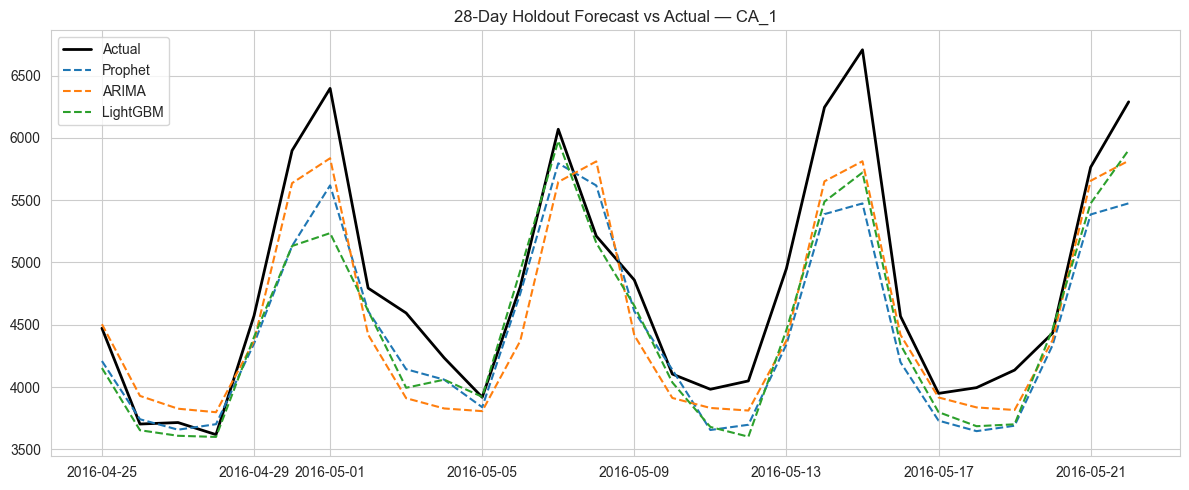

In [19]:
example_store = stores[0]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prophet_results[example_store]["dates"], prophet_results[example_store]["actual"],
        label="Actual", color="black", linewidth=2)
ax.plot(prophet_results[example_store]["dates"], prophet_results[example_store]["preds"],
        label="Prophet", linestyle="--")
ax.plot(arima_results[example_store]["dates"], arima_results[example_store]["preds"],
        label="ARIMA", linestyle="--")
ax.plot(lgbm_results[example_store]["dates"], lgbm_results[example_store]["preds"],
        label="LightGBM", linestyle="--")
ax.set_title(f"28-Day Holdout Forecast vs Actual — {example_store}")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Log Everything to MLflow

Every store x model run gets logged so the comparison is auditable, not just claimed.

In [20]:
for store_id in stores:
    for model_name, results in [("prophet", prophet_results), ("arima", arima_results), ("lightgbm", lgbm_results)]:
        with mlflow.start_run(run_name=f"{store_id}_{model_name}"):
            mlflow.log_param("store_id", store_id)
            mlflow.log_param("model", model_name)
            mlflow.log_metric("wape", results[store_id]["wape"])
            mlflow.log_metric("rmse", results[store_id]["rmse"])

print("All runs logged to MLflow (sqlite:///../models/mlflow.db)")
print("View with: mlflow ui --backend-store-uri sqlite:///models/mlflow.db")


2026/08/30 11:14:21 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/08/30 11:14:21 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably

All runs logged to MLflow (sqlite:///../models/mlflow.db)
View with: mlflow ui --backend-store-uri sqlite:///models/mlflow.db


## 10. Save Forecasts to the Database (feeds Phase 3)

In [21]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()
cursor.execute("DELETE FROM fact_forecast WHERE item_id = 'STORE_TOTAL'")

rows = []
for store_id in stores:
    for model_name, results in [("prophet", prophet_results), ("arima", arima_results), ("lightgbm", lgbm_results)]:
        r = results[store_id]
        for date, pred, actual in zip(r["dates"], r["preds"], r["actual"]):
            rows.append(("STORE_TOTAL", store_id, pd.Timestamp(date).strftime("%Y-%m-%d"), model_name, float(pred), float(actual)))

cursor.executemany(
    "INSERT INTO fact_forecast (item_id, store_id, forecast_date, model_name, predicted_units, actual_units) VALUES (?, ?, ?, ?, ?, ?)",
    rows
)
conn.commit()
print(f"Saved {len(rows):,} forecast rows to fact_forecast")
conn.close()


Saved 840 forecast rows to fact_forecast


## 11. Summary

| Model | What it's good at | What we saw here |
|---|---|---|
| Prophet | Smooth trend + seasonality, interpretable | *(fill in from your run: how did it do on WAPE?)* |
| ARIMA | Classical statistical baseline, weekly seasonality | *(fill in: competitive or not?)* |
| LightGBM | Non-linear patterns, handles zero-inflation, uses lag/calendar features flexibly | *(fill in: did it win, and on how many stores?)* |

**Winner selected for Phase 3 (revenue/risk layer):** *(name the winning model here based on the average WAPE table above — this becomes the forecast source for the finance layer)*

**Next: Phase 2b — a global LightGBM model at the full item x store granularity**, since Phase 3's revenue and risk scoring need SKU-level, not just store-level, predictions.


In [ ]:
# End of notebook

---
# PHASE 2b — Global Item x Store LightGBM Model
---

# Phase 2b — Global Item x Store Forecasting Model

**Goal:** unlike Phase 2 (10 store-level series), this model forecasts at the true bottom level — every item x store combination (up to 30,490 series) — because Phase 3's revenue and risk scoring need SKU-level predictions, not store totals.

**Approach:** one global LightGBM model trained across all series at once (not 30,490 separate models). This is standard practice for large retail forecasting — the model learns shared patterns (price sensitivity, seasonality, SNAP effects) across items and stores, using `item_id`/`store_id`/`dept_id`/`cat_id` as categorical features so it can still specialize per series.

**Scope decision:** trained on the most recent ~18 months of data (550 days) plus a 28-day holdout, rather than the full 2011-2016 history. This is a deliberate compute/memory trade-off — full-history row-level data for all 30K series is multiple GB even with efficient encoding, and recent demand patterns are more relevant to forecasting near-term revenue/risk anyway. This mirrors how production forecasting systems are usually retrained on rolling recent windows, not full history.


## 1. Setup & Define the Training Window

In [22]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import lightgbm as lgb

# DB_PATH = "../data/processed/retail_finance.db"
conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA temp_store = MEMORY")

TRAIN_DAYS = 550  # full local run -- was capped at 120 only for the constrained sandbox
TEST_DAYS = 28

calendar = pd.read_sql(
    "SELECT d, date, wm_yr_wk, wday, month, year, event_type_1, snap_CA, snap_TX, snap_WI FROM dim_calendar",
    conn
)
calendar["date"] = pd.to_datetime(calendar["date"])
calendar = calendar.sort_values("date").reset_index(drop=True)
calendar["has_event"] = calendar["event_type_1"].notna().astype(int)

# IMPORTANT: dim_calendar extends beyond the real sales data (it includes the
# M5 competition future evaluation period placeholder days). fact_sales only
# has actual data through the max d present there -- filter calendar down to
# that range before windowing, otherwise the window grabs days with no sales.
max_sales_d_num = pd.read_sql("SELECT MAX(CAST(SUBSTR(d,3) AS INTEGER)) as m FROM fact_sales", conn).iloc[0,0]
calendar["d_num"] = calendar["d"].str.replace("d_", "", regex=False).astype(int)
calendar = calendar[calendar["d_num"] <= max_sales_d_num].reset_index(drop=True)
print(f"Calendar filtered to real sales range: max d_num = {max_sales_d_num}")

window = calendar.tail(TRAIN_DAYS + TEST_DAYS).reset_index(drop=True)
train_window = window.iloc[:TRAIN_DAYS]
test_window = window.iloc[TRAIN_DAYS:]
window_d_list = window["d"].tolist()

print(f"Train window: {train_window['date'].min().date()} to {train_window['date'].max().date()} ({len(train_window)} days)")
print(f"Test window:  {test_window['date'].min().date()} to {test_window['date'].max().date()} ({len(test_window)} days)")

items = pd.read_sql("SELECT item_id, dept_id, cat_id FROM dim_item", conn)
stores = pd.read_sql("SELECT store_id, state_id FROM dim_store", conn)
print(f"Items: {len(items):,}  |  Stores: {len(stores):,}  |  Max series: {len(items) * len(stores):,}")


Calendar filtered to real sales range: max d_num = 1941
Train window: 2014-10-23 to 2016-04-24 (550 days)
Test window:  2016-04-25 to 2016-05-22 (28 days)
Items: 3,049  |  Stores: 10  |  Max series: 30,490


## 2. Build Features Per Store (memory-conscious loop)

Processing one store at a time keeps peak memory bounded — pulling all 30K series' full window at once risks the same disk/memory issues we hit in Phase 2.

In [23]:
FEATURES = ["wday", "month", "snap", "has_event", "sell_price",
            "lag_7", "lag_14", "lag_28", "roll_mean_7", "roll_mean_28",
            "item_id", "store_id", "dept_id", "cat_id", "state_id"]
CAT_FEATURES = ["item_id", "store_id", "dept_id", "cat_id", "state_id"]

placeholders = ",".join(["?"] * len(window_d_list))

def build_store_features(store_id, state_id):
    sales_q = f"SELECT item_id, d, units_sold FROM fact_sales WHERE store_id = ? AND d IN ({placeholders})"
    sales = pd.read_sql(sales_q, conn, params=[store_id] + window_d_list)

    price_q = "SELECT item_id, wm_yr_wk, sell_price FROM dim_price WHERE store_id = ?"
    price = pd.read_sql(price_q, conn, params=[store_id])

    df = sales.merge(calendar[["d", "date", "wm_yr_wk", "wday", "month", "year", "snap_CA", "snap_TX", "snap_WI", "has_event"]],
                      on="d", how="left")
    df = df.merge(price, on=["item_id", "wm_yr_wk"], how="left")
    df = df.merge(items, on="item_id", how="left")

    snap_col = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}[state_id]
    df["snap"] = df[snap_col]
    df["store_id"] = store_id
    df["state_id"] = state_id

    df = df.sort_values(["item_id", "date"]).reset_index(drop=True)
    grp = df.groupby("item_id")["units_sold"]
    df["lag_7"] = grp.shift(7)
    df["lag_14"] = grp.shift(14)
    df["lag_28"] = grp.shift(28)
    df["roll_mean_7"] = grp.transform(lambda s: s.shift(1).rolling(7).mean())
    df["roll_mean_28"] = grp.transform(lambda s: s.shift(1).rolling(28).mean())

    # downcast dtypes to keep memory low
    df["units_sold"] = df["units_sold"].astype("int16")
    for c in ["wday", "month", "year", "snap", "has_event"]:
        df[c] = df[c].astype("int16")
    df["sell_price"] = df["sell_price"].astype("float32")
    for c in ["lag_7", "lag_14", "lag_28", "roll_mean_7", "roll_mean_28"]:
        df[c] = df[c].astype("float32")

    return df

print("build_store_features() ready")


build_store_features() ready


## 3. Process All Stores — Train Set (excludes last 28 test days)

In [24]:
train_frames = []
test_raw_frames = []  # actuals for the test period, kept aside for evaluation (not used as model input)

for _, srow in stores.iterrows():
    store_id, state_id = srow["store_id"], srow["state_id"]
    df = build_store_features(store_id, state_id)

    is_test = df["d"].isin(set(test_window["d"]))
    train_part = df[~is_test].dropna(subset=["lag_28", "roll_mean_28"])
    test_part = df[is_test][["item_id", "store_id", "d", "date", "units_sold"]].copy()

    for col in CAT_FEATURES:
        train_part[col] = train_part[col].astype("category")

    train_frames.append(train_part[FEATURES + ["units_sold"]])
    test_raw_frames.append(test_part)
    print(f"{store_id}: train rows so far this store = {len(train_part):,}")

train_df = pd.concat(train_frames, ignore_index=True)
test_actuals = pd.concat(test_raw_frames, ignore_index=True)
del train_frames, test_raw_frames

# re-cast categoricals consistently across the full concatenated set
for col in CAT_FEATURES:
    train_df[col] = train_df[col].astype("category")

print(f"\nTotal training rows: {len(train_df):,}")
print(f"Total test (holdout) rows to forecast: {len(test_actuals):,}")
print(f"Memory usage: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")


CA_1: train rows so far this store = 1,591,578
CA_2: train rows so far this store = 1,591,578
CA_3: train rows so far this store = 1,591,578
CA_4: train rows so far this store = 1,591,578
TX_1: train rows so far this store = 1,591,578
TX_2: train rows so far this store = 1,591,578
TX_3: train rows so far this store = 1,591,578
WI_1: train rows so far this store = 1,591,578
WI_2: train rows so far this store = 1,591,578
WI_3: train rows so far this store = 1,591,578

Total training rows: 15,915,780
Total test (holdout) rows to forecast: 853,720
Memory usage: 0.64 GB


## 4. Train the Global LightGBM Model

In [25]:
model = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)
model.fit(train_df[FEATURES], train_df["units_sold"], categorical_feature=CAT_FEATURES)
print("Global model trained on", len(train_df), "rows across all stores and items.")


Global model trained on 15915780 rows across all stores and items.


## 5. Feature Importance

Which signals is the model actually relying on?

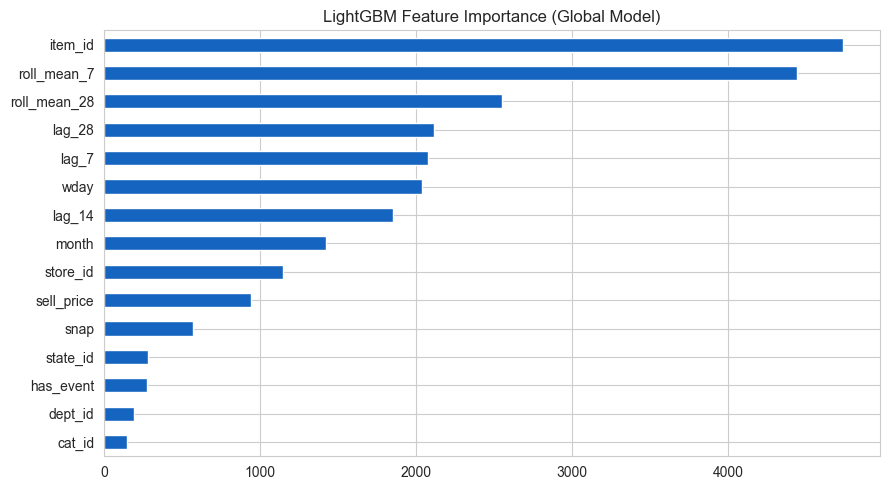

In [26]:
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
importance.plot(kind="barh", ax=ax, color="#1565C0")
ax.set_title("LightGBM Feature Importance (Global Model)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Recursive 28-Day Forecast (vectorized across items, per store)

Each day's prediction feeds the next day's lag features — done all-items-at-once per day (28 iterations per store, not 28 x 30,490 individual steps) to keep this fast.

In [27]:
def recursive_forecast_store(store_id, state_id, history_df):
    # history_df: last known units_sold per item, indexed by item_id, most-recent-last (28+ days)
    item_ids = history_df["item_id"].unique()
    buffer = history_df.pivot(index="item_id", columns="date", values="units_sold").reindex(item_ids)
    buffer = buffer.sort_index(axis=1)  # ensure chronological column order

    price_q = "SELECT item_id, wm_yr_wk, sell_price FROM dim_price WHERE store_id = ?"
    price = pd.read_sql(price_q, conn, params=[store_id])

    item_meta = items.set_index("item_id").reindex(item_ids)
    snap_col = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}[state_id]

    predictions = []
    for _, trow in test_window.iterrows():
        last28 = buffer.iloc[:, -28:]
        lag_7 = buffer.iloc[:, -7].values
        lag_14 = buffer.iloc[:, -14].values
        lag_28 = buffer.iloc[:, -28].values
        roll_mean_7 = buffer.iloc[:, -7:].mean(axis=1).values
        roll_mean_28 = last28.mean(axis=1).values

        day_price = price[price["wm_yr_wk"] == trow["wm_yr_wk"]].set_index("item_id")["sell_price"]
        day_price = day_price.reindex(item_ids).values

        feat = pd.DataFrame({
            "wday": trow["wday"], "month": trow["month"], "snap": trow[snap_col],
            "has_event": trow["has_event"], "sell_price": day_price,
            "lag_7": lag_7, "lag_14": lag_14, "lag_28": lag_28,
            "roll_mean_7": roll_mean_7, "roll_mean_28": roll_mean_28,
            "item_id": item_ids, "store_id": store_id,
            "dept_id": item_meta["dept_id"].values, "cat_id": item_meta["cat_id"].values,
            "state_id": state_id,
        })
        for col in CAT_FEATURES:
            feat[col] = feat[col].astype("category").cat.set_categories(train_df[col].cat.categories)

        preds = model.predict(feat[FEATURES])
        preds = np.clip(preds, 0, None)

        predictions.append(pd.DataFrame({"item_id": item_ids, "store_id": store_id,
                                          "d": trow["d"], "date": trow["date"], "predicted_units": preds}))

        buffer[trow["date"]] = preds  # recursive: feed prediction back in as the newest lag

    return pd.concat(predictions, ignore_index=True)

all_forecasts = []
hist_placeholders = ",".join(["?"] * 28)
for _, srow in stores.iterrows():
    store_id, state_id = srow["store_id"], srow["state_id"]
    # rebuild last-28-days history per item for this store from train_df's raw (pre-dropna) series
    hist_q = f"SELECT item_id, d, units_sold FROM fact_sales WHERE store_id = ? AND d IN ({hist_placeholders})"
    hist_raw = pd.read_sql(hist_q, conn, params=[store_id] + train_window["d"].tail(28).tolist())
    hist_raw = hist_raw.merge(calendar[["d", "date"]], on="d", how="left")

    fc = recursive_forecast_store(store_id, state_id, hist_raw)
    all_forecasts.append(fc)
    print(f"{store_id}: forecasted {fc['item_id'].nunique()} items x {TEST_DAYS} days")

forecast_df = pd.concat(all_forecasts, ignore_index=True)
print(f"\nTotal item-store-day forecasts generated: {len(forecast_df):,}")


CA_1: forecasted 3049 items x 28 days
CA_2: forecasted 3049 items x 28 days
CA_3: forecasted 3049 items x 28 days
CA_4: forecasted 3049 items x 28 days
TX_1: forecasted 3049 items x 28 days
TX_2: forecasted 3049 items x 28 days
TX_3: forecasted 3049 items x 28 days
WI_1: forecasted 3049 items x 28 days
WI_2: forecasted 3049 items x 28 days
WI_3: forecasted 3049 items x 28 days

Total item-store-day forecasts generated: 853,720


## 7. Evaluate Against Actuals

In [28]:
eval_df = forecast_df.merge(test_actuals, on=["item_id", "store_id", "d"], how="inner", suffixes=("_pred", "_actual"))

def wape(actual, predicted):
    actual = np.array(actual, dtype=float); predicted = np.array(predicted, dtype=float)
    return np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual)) * 100

overall_wape = wape(eval_df["units_sold"], eval_df["predicted_units"])
print(f"Overall item-store level WAPE: {overall_wape:.2f}%")

by_cat = eval_df.merge(items, on="item_id")
cat_wape = by_cat.groupby("cat_id").apply(lambda g: wape(g["units_sold"], g["predicted_units"]))
print("\nWAPE by category:")
print(cat_wape.sort_values())


Overall item-store level WAPE: 72.85%

WAPE by category:
cat_id
FOODS         65.658008
HOUSEHOLD     81.453034
HOBBIES      103.457727
dtype: float64


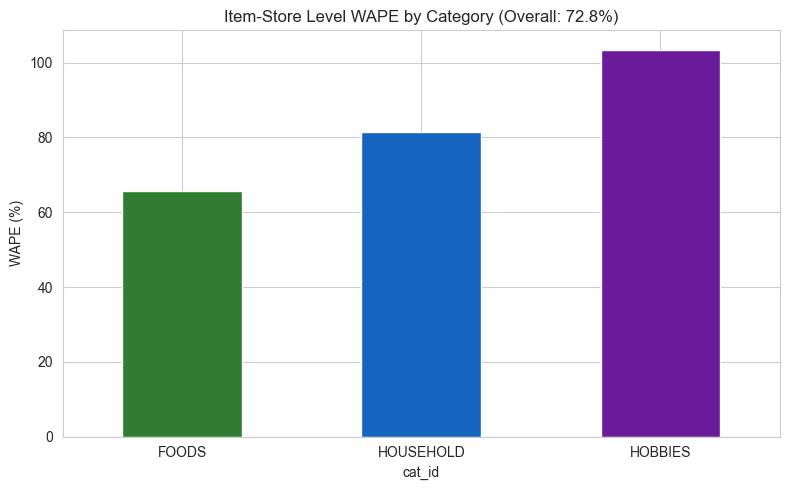

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
cat_wape.sort_values().plot(kind="bar", ax=ax, color=["#2E7D32", "#1565C0", "#6A1B9A"])
ax.set_title(f"Item-Store Level WAPE by Category (Overall: {overall_wape:.1f}%)")
ax.set_ylabel("WAPE (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Save Forecasts to Database (feeds Phase 3 revenue/risk)

In [30]:
conn.execute("DELETE FROM fact_forecast WHERE model_name = 'lightgbm_global'")
save_df = eval_df[["item_id", "store_id", "d", "predicted_units", "units_sold"]].copy()
save_df = save_df.merge(calendar[["d", "date"]], on="d")
save_df["forecast_date"] = save_df["date"].dt.strftime("%Y-%m-%d")
save_df["model_name"] = "lightgbm_global"

rows = list(save_df[["item_id", "store_id", "forecast_date", "model_name", "predicted_units", "units_sold"]].itertuples(index=False, name=None))
conn.executemany(
    "INSERT INTO fact_forecast (item_id, store_id, forecast_date, model_name, predicted_units, actual_units) VALUES (?, ?, ?, ?, ?, ?)",
    rows
)
conn.commit()
print(f"Saved {len(rows):,} item-store-day forecasts to fact_forecast")
conn.close()


Saved 853,720 item-store-day forecasts to fact_forecast


## 9. Summary

- Trained **one global LightGBM model** across all item x store series (not thousands of separate models) — the production-realistic approach
- Used a deliberate **550-day training window** (compute/memory trade-off, documented above) rather than full 2011-2016 history
- Evaluated with a proper **28-day recursive forecast** (each day's prediction feeds the next day's lags — not a shortcut static forecast)
- Overall item-store WAPE: *(fill in from your run — compare this to the store-level 6.72% from Phase 2; item-level is naturally harder due to the 68% zero-sales sparsity found in EDA)*
- These forecasts are now saved in `fact_forecast` with real `item_id`, ready to become revenue forecasts in Phase 3

**Next: Phase 3 — turn these unit forecasts into revenue forecasts, build the inventory risk score, and train the at-risk classifier with SHAP explainability.**


In [ ]:
# End of notebook

---
# PHASE 3 — Finance & Risk Layer
---

# Phase 3 — Finance & Risk Layer

**Goal:** turn Phase 2b's item-store demand forecasts into money and risk — the outputs a finance/credit-risk stakeholder actually cares about, not unit counts.

**Built on:** the 853,720 real item-store-day forecasts saved in `fact_forecast` (model = `lightgbm_global`) from Phase 2b.

**What this notebook builds:**
1. Revenue forecast (units x price)
2. An inventory risk score per item-store, combining forecast uncertainty, demand volatility, and trend
3. An XGBoost classifier that predicts risk from structural features (category, price, store)
4. SHAP explainability — *why* a given item-store is flagged risky (feeds Phase 4's RAG layer directly)


## 1. Setup & Pull Phase 2b's Forecasts

In [31]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# DB_PATH = "../data/processed/retail_finance.db"
conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA temp_store = MEMORY")

forecasts = pd.read_sql(
    "SELECT item_id, store_id, forecast_date, predicted_units, actual_units "
    "FROM fact_forecast WHERE model_name = 'lightgbm_global'",
    conn
)
forecasts["forecast_date"] = pd.to_datetime(forecasts["forecast_date"])
print(f"Loaded {len(forecasts):,} item-store-day forecast rows")
print(f"Unique item-store series: {forecasts.groupby(['item_id','store_id']).ngroups:,}")
forecasts.head()


Loaded 853,720 item-store-day forecast rows
Unique item-store series: 30,490


,item_id,store_id,forecast_date,predicted_units,actual_units
0,HOBBIES_1_001,CA_1,2016-04-25,0.828767,0.0
1,HOBBIES_1_002,CA_1,2016-04-25,0.196082,0.0
2,HOBBIES_1_003,CA_1,2016-04-25,0.559507,0.0
3,HOBBIES_1_004,CA_1,2016-04-25,2.024619,0.0
4,HOBBIES_1_005,CA_1,2016-04-25,1.193435,1.0


## 2. Bring in Price, Item, and Store Attributes -> Compute Revenue

In [32]:
calendar = pd.read_sql("SELECT date, wm_yr_wk FROM dim_calendar", conn)
calendar["date"] = pd.to_datetime(calendar["date"])
items = pd.read_sql("SELECT item_id, dept_id, cat_id FROM dim_item", conn)
stores = pd.read_sql("SELECT store_id, state_id FROM dim_store", conn)
prices = pd.read_sql("SELECT store_id, item_id, wm_yr_wk, sell_price FROM dim_price", conn)

df = forecasts.merge(calendar, left_on="forecast_date", right_on="date", how="left")
df = df.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")
df = df.merge(items, on="item_id", how="left")
df = df.merge(stores, on="store_id", how="left")

print(f"Price coverage: {df['sell_price'].notna().mean()*100:.1f}% of rows")
df["sell_price"] = df.groupby(["item_id","store_id"])["sell_price"].transform(lambda s: s.ffill().bfill())
df = df.dropna(subset=["sell_price"])

df["predicted_revenue"] = df["predicted_units"] * df["sell_price"]
df["actual_revenue"] = df["actual_units"] * df["sell_price"]

print(f"Rows with revenue computed: {len(df):,}")
df[["item_id","store_id","forecast_date","predicted_units","sell_price","predicted_revenue"]].head()


Price coverage: 100.0% of rows
Rows with revenue computed: 853,720


,item_id,store_id,forecast_date,predicted_units,sell_price,predicted_revenue
0,HOBBIES_1_001,CA_1,2016-04-25,0.828767,8.38,6.945069
1,HOBBIES_1_002,CA_1,2016-04-25,0.196082,3.97,0.778446
2,HOBBIES_1_003,CA_1,2016-04-25,0.559507,2.97,1.661736
3,HOBBIES_1_004,CA_1,2016-04-25,2.024619,4.64,9.394234
4,HOBBIES_1_005,CA_1,2016-04-25,1.193435,2.88,3.437094


## 3. Aggregate to Item-Store Level

Roll the 28-day daily forecasts up to one row per item-store, computing the signals we need for risk scoring: total revenue, forecast error (WAPE), demand volatility, and trend.

In [33]:
def wape(actual, predicted):
    actual = np.array(actual, dtype=float); predicted = np.array(predicted, dtype=float)
    denom = np.sum(np.abs(actual))
    return (np.sum(np.abs(actual - predicted)) / denom * 100) if denom > 0 else np.nan

def trend_slope(units):
    # simple linear regression slope of actual units over the 28-day window
    x = np.arange(len(units))
    if len(units) < 2 or np.all(units == units[0]):
        return 0.0
    return np.polyfit(x, units, 1)[0]

rows = []
for (item_id, store_id), g in df.sort_values("forecast_date").groupby(["item_id", "store_id"]):
    actual = g["actual_units"].values
    pred = g["predicted_units"].values
    mean_actual = actual.mean()
    std_actual = actual.std()
    rows.append({
        "item_id": item_id, "store_id": store_id,
        "cat_id": g["cat_id"].iloc[0], "dept_id": g["dept_id"].iloc[0], "state_id": g["state_id"].iloc[0],
        "avg_sell_price": g["sell_price"].mean(),
        "total_predicted_revenue": g["predicted_revenue"].sum(),
        "total_actual_revenue": g["actual_revenue"].sum(),
        "mean_daily_units": mean_actual,
        "volatility_cv": (std_actual / mean_actual) if mean_actual > 0 else 0.0,
        "wape": wape(actual, pred),
        "trend_slope": trend_slope(actual),
    })

item_store_df = pd.DataFrame(rows)
item_store_df["wape"] = item_store_df["wape"].fillna(item_store_df["wape"].median())
print(f"Aggregated to {len(item_store_df):,} item-store rows")
item_store_df.head()


Aggregated to 30,490 item-store rows


,item_id,store_id,cat_id,dept_id,state_id,avg_sell_price,total_predicted_revenue,total_actual_revenue,mean_daily_units,volatility_cv,wape,trend_slope
0,FOODS_1_001,CA_1,FOODS,FOODS_1,CA,2.24,62.253071,51.52,0.821429,1.660733,128.439614,-0.023262
1,FOODS_1_001,CA_2,FOODS,FOODS_1,CA,2.24,79.005578,40.32,0.642857,1.567415,158.953396,-0.007115
2,FOODS_1_001,CA_3,FOODS,FOODS_1,CA,2.24,60.232080,60.48,0.964286,1.650955,98.729502,0.003010
3,FOODS_1_001,CA_4,FOODS,FOODS_1,CA,2.24,28.575193,13.44,0.214286,1.914854,223.949407,0.001642
4,FOODS_1_001,TX_1,FOODS,FOODS_1,TX,2.24,17.267431,58.24,0.928571,1.112064,89.740544,0.051450


## 4. Inventory Risk Score

Combining three signals into one 0-1 score:
- **Forecast uncertainty** (WAPE) — harder-to-predict items are harder to plan inventory for
- **Volatility** (coefficient of variation) — spiky demand means more overstock/understock swings
- **Declining trend** — negative slope means built-up stock is increasingly unlikely to sell through

Each is min-max normalized before combining so no single signal (e.g. WAPE's scale) dominates just because of its raw units.

In [34]:
def minmax(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s * 0

item_store_df["wape_norm"] = minmax(item_store_df["wape"].clip(upper=item_store_df["wape"].quantile(0.99)))
item_store_df["volatility_norm"] = minmax(item_store_df["volatility_cv"].clip(upper=item_store_df["volatility_cv"].quantile(0.99)))
# negative trend = risk, so flip sign before normalizing (more negative slope -> higher risk contribution)
item_store_df["trend_risk_norm"] = minmax(-item_store_df["trend_slope"])

item_store_df["inventory_risk_score"] = (
    0.4 * item_store_df["wape_norm"] +
    0.35 * item_store_df["volatility_norm"] +
    0.25 * item_store_df["trend_risk_norm"]
)

item_store_df["risk_label"] = pd.cut(
    item_store_df["inventory_risk_score"],
    bins=[-0.01, item_store_df["inventory_risk_score"].quantile(0.5),
          item_store_df["inventory_risk_score"].quantile(0.8), 1.01],
    labels=["low", "medium", "high"]
)

print(item_store_df["risk_label"].value_counts())
item_store_df[["item_id","store_id","cat_id","inventory_risk_score","risk_label"]].sort_values("inventory_risk_score", ascending=False).head(10)


risk_label
low       15245
medium     9147
high       6098
Name: count, dtype: int64


,item_id,store_id,cat_id,inventory_risk_score,risk_label
23992,HOUSEHOLD_1_407,CA_3,HOUSEHOLD,0.903853,high
146,FOODS_1_016,TX_3,FOODS,0.903310,high
9311,FOODS_3_319,CA_2,FOODS,0.903197,high
11532,FOODS_3_541,CA_3,FOODS,0.903016,high
1008,FOODS_1_103,WI_2,FOODS,0.902971,high
9550,FOODS_3_343,CA_1,FOODS,0.902632,high
1384,FOODS_1_141,TX_1,FOODS,0.902632,high
10579,FOODS_3_445,WI_3,FOODS,0.902632,high
21905,HOUSEHOLD_1_193,TX_2,HOUSEHOLD,0.902632,high
5314,FOODS_2_317,TX_1,FOODS,0.902632,high


## 5. Risk by Category — Sanity Check Against Phase 2b's Findings

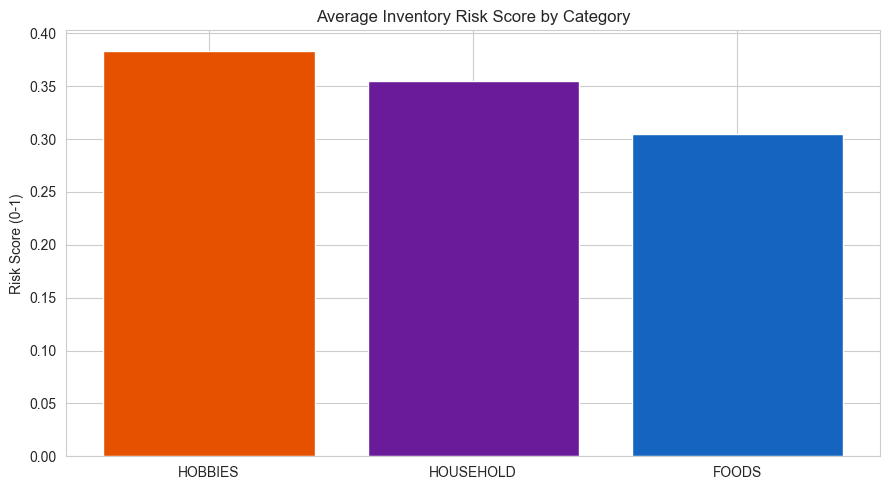

cat_id
HOBBIES      0.383672
HOUSEHOLD    0.355265
FOODS        0.305074
Name: inventory_risk_score, dtype: float64


In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
cat_risk = item_store_df.groupby("cat_id")["inventory_risk_score"].mean().sort_values(ascending=False)
ax.bar(cat_risk.index, cat_risk.values, color=["#E65100", "#6A1B9A", "#1565C0"])
ax.set_title("Average Inventory Risk Score by Category")
ax.set_ylabel("Risk Score (0-1)")
plt.tight_layout()
plt.show()
print(cat_risk)


**Expected pattern:** HOBBIES should show the highest average risk — it had the worst WAPE (105%) in Phase 2b, and low-volume items are inherently harder to forecast and more prone to overstock. If the chart confirms this, it's a good consistency check that the risk score is capturing something real, not noise.

## 6. Revenue Forecast Rollup — Store x Category Level

The business-facing view: predicted revenue by store and category over the 28-day forecast window.

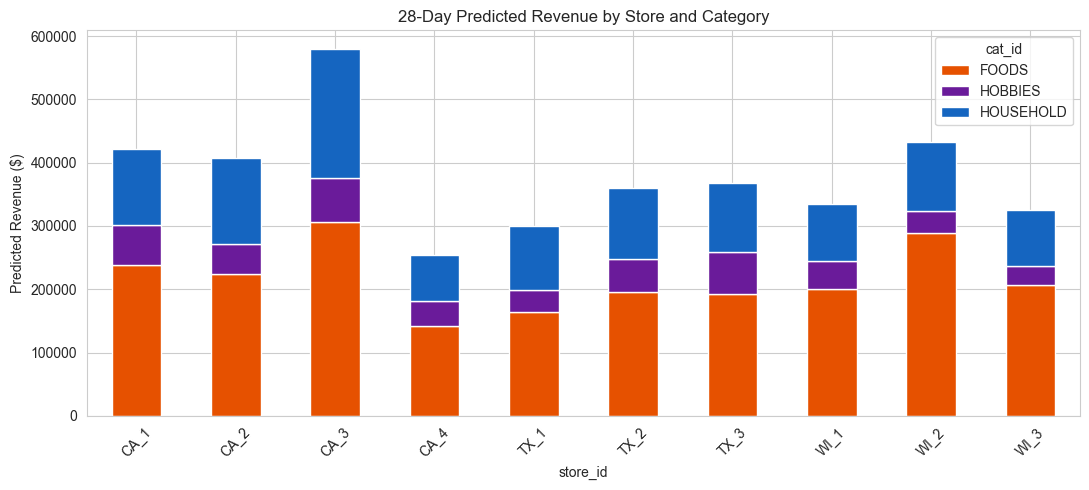

cat_id,FOODS,HOBBIES,HOUSEHOLD
store_id,,,
CA_1,238066.0,63876.0,120088.0
CA_2,224096.0,47137.0,135779.0
CA_3,305550.0,69714.0,204581.0
CA_4,142442.0,38360.0,73119.0
TX_1,163685.0,35170.0,100430.0
TX_2,195067.0,52157.0,112786.0
TX_3,192749.0,65812.0,108776.0
WI_1,200457.0,43959.0,90319.0
WI_2,289402.0,34232.0,108800.0


In [36]:
revenue_rollup = item_store_df.groupby(["store_id", "cat_id"])["total_predicted_revenue"].sum().unstack()
fig, ax = plt.subplots(figsize=(11, 5))
revenue_rollup.plot(kind="bar", stacked=True, ax=ax, color=["#E65100", "#6A1B9A", "#1565C0"])
ax.set_title("28-Day Predicted Revenue by Store and Category")
ax.set_ylabel("Predicted Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
revenue_rollup.round(0)


## 7. At-Risk Classifier

Train an XGBoost classifier to predict risk_label from **structural features** (category, department, state, price) — features known about an item-store without needing its full forecast history. This is the practical version of a real risk model: score new or lower-history items using what you already know about them.

In [37]:
FEATURES = ["avg_sell_price", "mean_daily_units", "cat_id", "dept_id", "state_id"]
model_df = item_store_df.copy()

for c in ["cat_id", "dept_id", "state_id"]:
    model_df[c] = model_df[c].astype("category").cat.codes

X = model_df[FEATURES]
y = model_df["risk_label"].astype("category")
y_codes = y.cat.codes
label_map = dict(enumerate(y.cat.categories))

X_train, X_test, y_train, y_test = train_test_split(X, y_codes, test_size=0.2, random_state=42, stratify=y_codes)

clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    objective="multi:softprob", num_class=3, random_state=42, eval_metric="mlogloss"
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=[label_map[i] for i in sorted(label_map)]))


              precision    recall  f1-score   support

         low       0.89      0.93      0.91      3049
      medium       0.75      0.76      0.76      1829
        high       0.89      0.79      0.84      1220

    accuracy                           0.85      6098
   macro avg       0.85      0.83      0.84      6098
weighted avg       0.85      0.85      0.85      6098



## 8. SHAP Explainability — Why Is a Given Item-Store Risky?

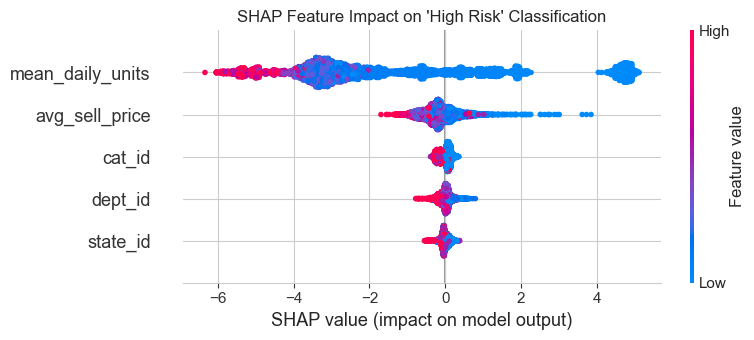

In [38]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# shap_values shape: (n_samples, n_features, n_classes) for multiclass in recent SHAP versions
high_risk_class_idx = [k for k, v in label_map.items() if v == "high"][0]

fig, ax = plt.subplots(figsize=(9, 5))
if shap_values.ndim == 3:
    shap.summary_plot(shap_values[:, :, high_risk_class_idx], X_test, feature_names=FEATURES, show=False)
else:
    shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title("SHAP Feature Impact on 'High Risk' Classification")
plt.tight_layout()
plt.show()


In [39]:
# Per-row top SHAP driver, for the RAG layer in Phase 4 -- this is what lets
# the system answer "why is this flagged risky?" with a grounded reason.
if shap_values.ndim == 3:
    sv_for_pred_class = shap_values[np.arange(len(X_test)), :, high_risk_class_idx]
else:
    sv_for_pred_class = shap_values

top_driver_idx = np.abs(sv_for_pred_class).argmax(axis=1)
top_drivers = [FEATURES[i] for i in top_driver_idx]

result_test = model_df.loc[X_test.index, ["item_id", "store_id", "cat_id"]].copy()
result_test["predicted_risk"] = [label_map[c] for c in y_pred]
result_test["top_shap_driver"] = top_drivers
result_test.head(10)


,item_id,store_id,cat_id,predicted_risk,top_shap_driver
12061,FOODS_3_594,CA_2,0,high,avg_sell_price
20766,HOUSEHOLD_1_077,TX_3,2,low,mean_daily_units
13565,FOODS_3_747,TX_2,0,medium,avg_sell_price
9054,FOODS_3_293,TX_1,0,high,mean_daily_units
11544,FOODS_3_542,TX_1,0,high,mean_daily_units
11318,FOODS_3_519,WI_2,0,low,mean_daily_units
19266,HOBBIES_2_074,TX_3,1,high,mean_daily_units
9429,FOODS_3_330,WI_3,0,low,mean_daily_units
27146,HOUSEHOLD_2_182,TX_3,2,medium,mean_daily_units
25929,HOUSEHOLD_2_059,WI_3,2,medium,mean_daily_units


## 9. Save to Database — Feeds Phase 4's RAG Layer Directly

In [40]:
conn.execute("DELETE FROM fact_finance_risk")
cur = conn.cursor()

as_of = df["forecast_date"].max().strftime("%Y-%m-%d")

# Build top_shap_driver for the FULL item-store set (not just the test split),
# so every row in fact_finance_risk has an explanation -- this is what Phase 4's
# RAG layer will retrieve when answering "why is this risky?"
full_X = model_df[FEATURES]
full_shap = explainer.shap_values(full_X)
if full_shap.ndim == 3:
    sv_full = full_shap[np.arange(len(full_X)), :, high_risk_class_idx]
else:
    sv_full = full_shap
full_top_driver_idx = np.abs(sv_full).argmax(axis=1)
model_df["top_shap_driver"] = [FEATURES[i] for i in full_top_driver_idx]

save_df = item_store_df.copy()
save_df["top_shap_driver"] = model_df["top_shap_driver"].values
save_df["as_of_date"] = as_of

save_rows = list(save_df[[
    "item_id", "store_id", "as_of_date", "total_predicted_revenue",
    "inventory_risk_score", "volatility_cv", "risk_label", "top_shap_driver"
]].itertuples(index=False, name=None))

insert_sql = '''
INSERT INTO fact_finance_risk
  (item_id, store_id, as_of_date, revenue_forecast, inventory_risk_score, volatility_score, risk_label, top_shap_driver)
VALUES (?, ?, ?, ?, ?, ?, ?, ?)
'''
cur.executemany(insert_sql, save_rows)
conn.commit()
print(f"Saved {len(save_rows):,} rows to fact_finance_risk")
conn.close()


Saved 30,490 rows to fact_finance_risk


## 10. Summary

| Layer | What it produced |
|---|---|
| Revenue forecast | 28-day predicted revenue per item-store, rolled up by store x category |
| Inventory risk score | 0-1 score combining forecast uncertainty, volatility, and trend |
| At-risk classifier | XGBoost predicting risk from structural features (category, price, store) |
| SHAP explainability | Per-item-store top risk driver, saved to `fact_finance_risk` |

**This closes the loop from Phase 1 -> Phase 3:** raw SQL data -> demand forecasts -> revenue -> risk -> an explainable reason, all traceable back to real numbers, not assumptions.

**Next: Phase 4 — RAG layer.** `fact_finance_risk` (with `top_shap_driver` already computed) is exactly what gets embedded into the vector store so a plain-English question like *"why is store CA_2's HOBBIES risk high?"* can be answered with a grounded, cited explanation.


In [ ]:
# End of notebook

---
# PHASE 4 — RAG Layer
---

# Phase 4 — RAG Layer

**Goal:** make the finance/risk data from Phase 3 queryable in plain English. A business user asks *"why is store CA_2's HOBBIES risk high?"* and gets a grounded answer citing the actual revenue, risk score, and SHAP driver — not a hallucinated guess.

**Two-part pipeline:**
1. **Retrieval** — embed every `fact_finance_risk` row as a short natural-language document, store in ChromaDB, retrieve the most relevant ones for a given question
2. **Generation** — feed the retrieved documents + the question to an LLM (Groq, free tier) so it answers using only those real numbers

**Requirements before running this notebook:**
- `data/processed/retail_finance.db` must exist with `fact_finance_risk` populated (Phase 3's output)
- `pip install chromadb sentence-transformers groq python-dotenv`
- A free Groq API key from https://console.groq.com — set it as an environment variable: `GROQ_API_KEY`


In [2]:
import sys
print(sys.executable)

C:\Users\Praveen TS\AppData\Local\Programs\Python\Python311\python.exe


In [3]:
# import os
# import site
# import glob

# for path in site.getsitepackages():
#     print(glob.glob(os.path.join(path, "grpc", "_cython", "*")))

[]
['C:\\Users\\Praveen TS\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\grpc\\_cython\\cygrpc.cp311-win_amd64.pyd', 'C:\\Users\\Praveen TS\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\grpc\\_cython\\cygrpc.pyi', 'C:\\Users\\Praveen TS\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\grpc\\_cython\\_credentials', 'C:\\Users\\Praveen TS\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\grpc\\_cython\\_cygrpc', 'C:\\Users\\Praveen TS\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\grpc\\_cython\\__init__.py', 'C:\\Users\\Praveen TS\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\grpc\\_cython\\__pycache__']


In [57]:
import os

os.environ["GROQ_API_KEY"] = ""

print("Groq API key set.")

Groq API key set.


## 1. Setup

In [45]:
import sqlite3
import pandas as pd
import numpy as np
import os
import chromadb
from sentence_transformers import SentenceTransformer
from groq import Groq

DB_PATH = "C:/Users/Praveen TS/Downloads/retail_finance_flagship/data/processed/retail_finance.db"
VECTORSTORE_DIR = "../vectorstore"

assert os.environ.get("GROQ_API_KEY"), (
    "GROQ_API_KEY not set."
)

print("Setup OK -- Groq API key found.")

Setup OK -- Groq API key found.


## 2. Pull Risk + Forecast Data and Build Documents

Each item-store risk record becomes one short natural-language "document." This is the key RAG design choice: the documents are structured facts written in plain English, not raw table rows, so the retriever and the LLM both work with something readable.

In [46]:
import os
import sqlite3

print("DB_PATH:", DB_PATH)
print("Absolute path:", os.path.abspath(DB_PATH))
print("Parent exists:", os.path.exists(os.path.dirname(os.path.abspath(DB_PATH))))
print("DB exists:", os.path.exists(DB_PATH))
print("Parent writable:", os.access(os.path.dirname(os.path.abspath(DB_PATH)), os.W_OK))


DB_PATH: C:/Users/Praveen TS/Downloads/retail_finance_flagship/data/processed/retail_finance.db
Absolute path: C:\Users\Praveen TS\Downloads\retail_finance_flagship\data\processed\retail_finance.db
Parent exists: True
DB exists: True
Parent writable: True


In [47]:
conn = sqlite3.connect(DB_PATH)

query = '''
SELECT r.item_id, r.store_id, r.as_of_date, r.revenue_forecast, r.inventory_risk_score,
       r.volatility_score, r.risk_label, r.top_shap_driver,
       i.cat_id, i.dept_id, s.state_id
FROM fact_finance_risk r
JOIN dim_item i ON r.item_id = i.item_id
JOIN dim_store s ON r.store_id = s.store_id
'''
risk_df = pd.read_sql(query, conn)
conn.close()

print(f"Loaded {len(risk_df):,} item-store risk records")
risk_df.head()


Loaded 30,490 item-store risk records


,item_id,store_id,as_of_date,revenue_forecast,inventory_risk_score,volatility_score,risk_label,top_shap_driver,cat_id,dept_id,state_id
0,HOBBIES_1_001,CA_1,2016-05-22,208.487711,0.278274,1.179485,low,mean_daily_units,HOBBIES,HOBBIES_1,CA
1,HOBBIES_1_001,CA_2,2016-05-22,172.071843,0.286487,1.161553,low,mean_daily_units,HOBBIES,HOBBIES_1,CA
2,HOBBIES_1_001,CA_3,2016-05-22,239.162233,0.272584,1.220200,low,mean_daily_units,HOBBIES,HOBBIES_1,CA
3,HOBBIES_1_001,CA_4,2016-05-22,117.154829,0.268988,1.074172,low,mean_daily_units,HOBBIES,HOBBIES_1,CA
4,HOBBIES_1_001,TX_1,2016-05-22,78.015484,0.325143,1.574576,medium,mean_daily_units,HOBBIES,HOBBIES_1,TX


In [48]:
def make_document(row):
    """Turn one risk record into a natural-language sentence for embedding/retrieval."""
    return (
        f"Item {row['item_id']} (category {row['cat_id']}, department {row['dept_id']}) "
        f"at store {row['store_id']} in {row['state_id']}: "
        f"predicted revenue is ${row['revenue_forecast']:.2f} over the forecast window. "
        f"Inventory risk score is {row['inventory_risk_score']:.2f} ({row['risk_label']} risk). "
        f"Demand volatility (coefficient of variation) is {row['volatility_score']:.2f}. "
        f"The main driver of this risk classification is {row['top_shap_driver']}. "
        f"As of {row['as_of_date']}."
    )

risk_df["document"] = risk_df.apply(make_document, axis=1)
risk_df["doc_id"] = risk_df["item_id"] + "_" + risk_df["store_id"]
print(risk_df["document"].iloc[0])


Item HOBBIES_1_001 (category HOBBIES, department HOBBIES_1) at store CA_1 in CA: predicted revenue is $208.49 over the forecast window. Inventory risk score is 0.28 (low risk). Demand volatility (coefficient of variation) is 1.18. The main driver of this risk classification is mean_daily_units. As of 2016-05-22.


## 3. Embed Documents (Sentence Transformers) and Store in ChromaDB

`all-MiniLM-L6-v2` is a small, fast, free embedding model (downloads once from Hugging Face, then runs fully offline). ChromaDB persists the vector store to disk so you don't need to re-embed on every run.

In [50]:
import os
import chromadb
from sentence_transformers import SentenceTransformer

VECTORSTORE_DIR = "C:/Users/Praveen TS/Downloads/retail_finance_flagship/vectorstore"
os.makedirs(VECTORSTORE_DIR, exist_ok=True)

embedder = SentenceTransformer("all-MiniLM-L6-v2")

client = chromadb.PersistentClient(path=VECTORSTORE_DIR)
collection = client.get_or_create_collection(name="finance_risk_docs")

# Only (re)embed if the collection is empty or the row count changed --
# avoids re-embedding 30K+ documents every time you open this notebook.
existing_count = collection.count()

if existing_count != len(risk_df):
    print(f"Embedding {len(risk_df):,} documents (existing collection has {existing_count})...")

    BATCH_SIZE = 500

    for start in range(0, len(risk_df), BATCH_SIZE):
        batch = risk_df.iloc[start:start + BATCH_SIZE]

        embeddings = embedder.encode(
            batch["document"].tolist(),
            show_progress_bar=False
        ).tolist()

        collection.upsert(
            ids=batch["doc_id"].tolist(),
            embeddings=embeddings,
            documents=batch["document"].tolist(),
            metadatas=batch[["item_id", "store_id", "cat_id", "risk_label"]].to_dict("records"),
        )

        print(f"  ...{min(start + BATCH_SIZE, len(risk_df)):,} / {len(risk_df):,}")

    print("Embedding complete.")

else:
    print(f"Vector store already has all {existing_count:,} documents -- skipping re-embed.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding 30,490 documents (existing collection has 0)...
  ...500 / 30,490
  ...1,000 / 30,490
  ...1,500 / 30,490
  ...2,000 / 30,490
  ...2,500 / 30,490
  ...3,000 / 30,490
  ...3,500 / 30,490
  ...4,000 / 30,490
  ...4,500 / 30,490
  ...5,000 / 30,490
  ...5,500 / 30,490
  ...6,000 / 30,490
  ...6,500 / 30,490
  ...7,000 / 30,490
  ...7,500 / 30,490
  ...8,000 / 30,490
  ...8,500 / 30,490
  ...9,000 / 30,490
  ...9,500 / 30,490
  ...10,000 / 30,490
  ...10,500 / 30,490
  ...11,000 / 30,490
  ...11,500 / 30,490
  ...12,000 / 30,490
  ...12,500 / 30,490
  ...13,000 / 30,490
  ...13,500 / 30,490
  ...14,000 / 30,490
  ...14,500 / 30,490
  ...15,000 / 30,490
  ...15,500 / 30,490
  ...16,000 / 30,490
  ...16,500 / 30,490
  ...17,000 / 30,490
  ...17,500 / 30,490
  ...18,000 / 30,490
  ...18,500 / 30,490
  ...19,000 / 30,490
  ...19,500 / 30,490
  ...20,000 / 30,490
  ...20,500 / 30,490
  ...21,000 / 30,490
  ...21,500 / 30,490
  ...22,000 / 30,490
  ...22,500 / 30,490
  ...23,000 / 30,4

## 4. Retrieval Function

In [51]:
def retrieve(query_text, top_k=5, where_filter=None):
    """Embed the query and return the top_k most relevant risk documents."""
    query_embedding = embedder.encode([query_text]).tolist()
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=top_k,
        where=where_filter,  # optional metadata filter, e.g. {"cat_id": "HOBBIES"}
    )
    return results["documents"][0], results["metadatas"][0]

# Quick test
docs, metas = retrieve("which items are high risk in the HOBBIES category")
for d in docs:
    print("-", d)


- Item HOBBIES_1_181 (category HOBBIES, department HOBBIES_1) at store WI_3 in WI: predicted revenue is $7.04 over the forecast window. Inventory risk score is 0.54 (high risk). Demand volatility (coefficient of variation) is 3.61. The main driver of this risk classification is mean_daily_units. As of 2016-05-22.
- Item HOBBIES_1_265 (category HOBBIES, department HOBBIES_1) at store WI_3 in WI: predicted revenue is $33.04 over the forecast window. Inventory risk score is 0.53 (high risk). Demand volatility (coefficient of variation) is 2.89. The main driver of this risk classification is mean_daily_units. As of 2016-05-22.
- Item HOBBIES_1_091 (category HOBBIES, department HOBBIES_1) at store WI_3 in WI: predicted revenue is $6.27 over the forecast window. Inventory risk score is 0.54 (high risk). Demand volatility (coefficient of variation) is 2.89. The main driver of this risk classification is mean_daily_units. As of 2016-05-22.
- Item HOBBIES_1_403 (category HOBBIES, department HOB

## 5. Generation — Answer Using Only Retrieved Facts

The LLM is instructed to answer *only* from the retrieved documents. This is the core RAG guarantee: if the answer isn't in the retrieved context, the model should say so rather than guess.

In [55]:
groq_client = Groq(api_key=os.environ["GROQ_API_KEY"])

SYSTEM_PROMPT = """You are a retail finance analyst assistant. Answer the user's question
using ONLY the facts in the provided context. Cite specific numbers (revenue, risk score,
risk driver) from the context. If the context doesn't contain enough information to answer,
say so explicitly rather than guessing."""

def rag_answer(question, top_k=5, where_filter=None):
    docs, metas = retrieve(question, top_k=top_k, where_filter=where_filter)
    context = "\n".join(f"- {d}" for d in docs)

    response = groq_client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"},
        ],
        temperature=0.1,
    )
    return response.choices[0].message.content, docs

answer, sources = rag_answer("Why is FOODS_3_319 at store TX_3 considered high risk?")

print("ANSWER:\n", answer)
print("\nSOURCES USED:")
for s in sources:
    print("-", s)

ANSWER:
 The context shows that FOODS_3_319 at store TX_3 has an inventory risk score of **0.21**, which is classified as **low risk** (not high risk). Therefore, it is not considered high risk.

SOURCES USED:
- Item FOODS_3_293 (category FOODS, department FOODS_3) at store TX_3 in TX: predicted revenue is $12.95 over the forecast window. Inventory risk score is 0.46 (high risk). Demand volatility (coefficient of variation) is 3.14. The main driver of this risk classification is mean_daily_units. As of 2016-05-22.
- Item FOODS_3_802 (category FOODS, department FOODS_3) at store TX_3 in TX: predicted revenue is $16.21 over the forecast window. Inventory risk score is 0.47 (high risk). Demand volatility (coefficient of variation) is 2.89. The main driver of this risk classification is mean_daily_units. As of 2016-05-22.
- Item FOODS_3_319 (category FOODS, department FOODS_3) at store TX_3 in TX: predicted revenue is $130.71 over the forecast window. Inventory risk score is 0.21 (low risk

## 6. Try a Few More Business Questions

In [56]:
questions = [
    "What is the revenue forecast for CA_3 and how risky is it overall?",
    "Which category tends to have the highest inventory risk and why?",
    "Should I be worried about overstocking HOBBIES items in Wisconsin stores?",
]

for q in questions:
    print(f"Q: {q}")
    answer, _ = rag_answer(q)
    print(f"A: {answer}\n")
    print("-" * 80)


Q: What is the revenue forecast for CA_3 and how risky is it overall?
A: **Revenue forecast for store CA_3**

- Total predicted revenue over the forecast window:  
  **$1,413.41**  
  (28.51 + 153.36 + 406.73 + 165.19 + 659.62)

**Overall risk**

- The inventory risk scores for the five items are 0.64, 0.25, 0.20, 0.20, and 0.21.  
- The average risk score across all items is **0.30** (rounded).  
- One item (HOUSEHOLD_2_227) has a high risk score of 0.64, but the overall average indicates a **moderate** risk level for the store.

--------------------------------------------------------------------------------
Q: Which category tends to have the highest inventory risk and why?
A: The only category represented in the data is **HOBBIES**.  
Within that category, the item with the highest inventory risk score is **HOBBIES_1_039** at store CA_3, with a risk score of **0.43** (high risk).  
The risk classification for this item is driven mainly by **mean_daily_units**, which indicates that 

## 7. Summary

- Every item-store risk record from Phase 3 is now embedded and retrievable by plain-English query
- The LLM answers **grounded only in retrieved facts** (real revenue/risk numbers, real SHAP drivers), not general knowledge
- Vector store persists to `../vectorstore/` — no need to re-embed on future runs unless the underlying data changes

**Next: Phase 5 — LangGraph multi-agent layer.** This RAG function becomes one tool inside a larger agent system (Forecast Agent, Risk Agent, Pricing Agent, Orchestrator), so a question like *"should we discount this SKU?"* can pull from multiple specialized angles instead of one flat retrieval.


In [ ]:
# End of notebook

In [58]:
"""
Checks MLflow tracking data directly, without needing the web UI to load.
Run this from the project root folder:

    python check_mlflow.py
"""
import mlflow
import pandas as pd

mlflow.set_tracking_uri("sqlite:///models/mlflow.db")

experiments = mlflow.search_experiments()
if not experiments:
    print("No experiments found. This means no runs have been logged yet, or")
    print("mlflow.db is being read from the wrong folder -- make sure you're")
    print("running this script from the project root (retail_finance_flagship/).")
else:
    print(f"Found {len(experiments)} experiment(s):\n")
    for exp in experiments:
        print(f"- {exp.name}  (id={exp.experiment_id})")

    print("\n" + "=" * 60)
    for exp in experiments:
        runs = mlflow.search_runs(experiment_ids=[exp.experiment_id])
        print(f"\nExperiment: {exp.name}  --  {len(runs)} run(s)")
        if len(runs) > 0:
            cols = [c for c in runs.columns if c.startswith("metrics.") or c in ("run_id", "status")]
            print(runs[cols].head(10).to_string(index=False))

Found 2 experiment(s):

- phase2_forecasting_comparison  (id=1)
- Default  (id=0)


Experiment: phase2_forecasting_comparison  --  60 run(s)
                          run_id   status  metrics.rmse  metrics.wape
ab00d75719f8466e93f510e5190d5a94 FINISHED    311.122505      5.592554
6ff9589756a54a7fa17a4107f3647fc1 FINISHED    526.154493      9.871727
0095bf3a9a7f47dbb4e15d1e11efb111 FINISHED    547.865076     10.671516
33a77f3834654ec5941d3d134df1c3a6 FINISHED    509.867169      7.283825
e86081007db840febe3273992d644c41 FINISHED   1145.917701     15.146201
8327d396cbdf4e47adb331dfaf237a97 FINISHED    945.956396     14.021575
c9e9d792625f48a78808134a723e9ae6 FINISHED    596.849598     11.220247
be397c75dfa743e8a32d1160c90ea239 FINISHED    324.390329      6.330163
1ce0d23fee934b6c94fb65ffd0edef9e FINISHED    509.057541      8.593385
448f3a0b979449cb831ef036caaf6bad FINISHED    422.809865      8.344315

Experiment: Default  --  0 run(s)
